# CLIP(Contrastive Language–Image Pretraining)
- 핵심 아이디어 : 이미지와 텍스트를 같은 임베딩 공간에 매핑하여, 두 모달리티를 동시에 이해한다.
- 이 실습은 구글 Colab에서 진행합니다.

- CLIP의 작동 원리 예시
    - "A photo of a dog" vs "A photo of a cat"
    - 입력 이미지 → Vision Encoder → Image embedding
    - 각 텍스트 후보 → Text Encoder → Text embedding
    - 두 벡터의 cosine similarity를 계산
        - 개 이미지에 "dog" 텍스트 벡터가 더 가까우면 → "dog"으로 분류

## 0.환경 준비

In [1]:
%pip install torch torchvision transformers pillow

In [2]:
import os
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

## 1. CLIP 모델 불러오기
### 1) Ultralytics 버전?

In [3]:
%pip install git+https://github.com/ultralytics/CLIP.git

  Cloning https://github.com/ultralytics/CLIP.git to /tmp/pip-req-build-6jsxk52q
  Running command git clone --filter=blob:none --quiet https://github.com/ultralytics/CLIP.git /tmp/pip-req-build-6jsxk52q
  Resolved https://github.com/ultralytics/CLIP.git to commit f5e9fc6a896e66309f07747bd607704f6c3d282a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#### 모델 불러오기

In [4]:
import torch
from PIL import Image

import clip

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model, preprocess = clip.load('ViT-B/32', device=device)

#### 이미지/텍스트 준비하기

In [5]:
image_path = '/content/dog.jpeg'
classes = ['a person', 'a car', 'a dog', 'a cat']

img = Image.open(image_path)

#### 모델에 넣을 준비

In [6]:
image = preprocess(img).unsqueeze(0).to(device)
text = clip.tokenize(classes).to(device)

#### 모델 실행(유사도 계산하기)

In [7]:
with torch.no_grad():
    logits_per_image, _ = model(image, text)
    print(logits_per_image)     # 이미지 기준으로 각 텍스트와 얼마나 맞는지 점수
    print("="*20)
    print(_)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    print("="*20)
    print(probs)

tensor([[21.5568, 20.6626, 26.0810, 20.0512]])
tensor([[21.5568],
        [20.6626],
        [26.0810],
        [20.0512]])
[0.01065508 0.00435721 0.9826235  0.00236418]


#### 결과

In [8]:
for label, prob in zip(classes, probs):
    print(f"{label}: {prob:.4f}")

a person: 0.0107
a car: 0.0044
a dog: 0.9826
a cat: 0.0024


In [9]:
prob_test = torch.tensor([0.0107, 0.0044, 0.9826, 0.0024])
classes = ["a person", "a car", "a dog", "a cat"]

# 'a dog'
print(prob_test.argmax())
print(classes[prob_test.argmax()])

tensor(2)
a dog


#### unsqueeze란?

In [10]:
# unsqueeze는 텐서에 크기가 1인 차원을 하나 추가하는 함수

import torch

x1 = torch.tensor([1.0, 2.0, 3.0])  # x1은 1차원 텐서, 즉, 값이 3개 있는 벡터
print(x1)
print(x1.shape)

x2 = x1.unsqueeze(0)    # unsqueeze(0)은 0번 위치, 즉 맨 앞에 차원 하나를 추가
print(x2)
print(x2.shape)

# 이게 필요한 이유는 딥러닝 모델들이 보통 입력을 배치 단위로 받기 때문.
# [3]은 데이터 1개처럼 보이지만, 모델 입장에서는 '배치 차원'이 없음
# [1, 3]은 '샘플 1개가 있고, 각 샘플을 값 3개를 가진다'는 뜻.

tensor([1., 2., 3.])
torch.Size([3])
tensor([[1., 2., 3.]])
torch.Size([1, 3])


## 2) HuggingFace 버전

#### 모델 불러오기

- 사전학습된 CLIP 모델과 입력 전처리를 담당하는 Processor를 로드한다.
    - `CLIPModel`: 이미지와 텍스트를 벡터로 바꿔주는 모델
    - `CLIPProcessor`: 이미지 크기 조정, 텍스트 토크나이징 등 자동 전처리
- https://huggingface.co/openai/clip-vit-base-patch32

In [11]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

####  이미지와 텍스트 프롬프트 준비
- 비교할 이미지와 여러 텍스트 문장을 준비.
- CLIP은 "이 이미지와 가장 잘 어울리는 문장은 무엇인가?"를 예측한다.

In [12]:
image_path = '/content/alpinist_frame00000.jpg'
print(image_path)
image = Image.open(image_path).convert("RGB")

texts = [
    "A person is climbing a snowy mountain.",
    "A soccer player is kicking the ball.",
    "A cat sitting on the chair.",
    "A landscape with a river and forest."
]

/content/alpinist_frame00000.jpg


#### 입력 전처리(Processor)
- 이미지와 문장을 CLIP이 읽을 수 있는 형태로 바꾼다.

In [13]:
inputs = processor(
    text=texts,
    images=image,
    return_tensors= 'pt',   # pytorch 텐서로 변환해서 사용하라는 말
    padding=True,
    truncation=True
)

#### 모델 실행(유사도 계산하기)
- 임베딩 추출 및 유사도 계산
- CLIP은 이미지와 텍스트를 같은 공간에 매핑하여 코사인 유사도 계산
- `logits_per_image`는 이미지와 각 문장의 유사도 점수


In [14]:
with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

In [15]:
print(probs)

['A person is climbing a snowy mountain.', 'A soccer player is kicking the ball.', 'A cat sitting on the chair.', 'A landscape with a river and forest.']


In [15]:
print(texts)

#### 결과
- 어떤 문장이 이미지와 가장 잘 맞는지 확인한다.
- 소프트맥스로 확률화 → 가장 높은 확률의 문장이 결과로 선택

In [25]:
for idx, (desc, prob) in enumerate(zip(texts, probs)):
    print(f"Text {idx+1}: \"{desc}\" | Matching score: {prob:.4f}")

print("Most likely description:", texts[probs.argmax()])


Text 1: "A person is climbing a snowy mountain." | Matching score: 0.9991
Text 2: "A soccer player is kicking the ball." | Matching score: 0.0004
Text 3: "A cat sitting on the chair." | Matching score: 0.0003
Text 4: "A landscape with a river and forest." | Matching score: 0.0002
Most likely description: A person is climbing a snowy mountain.


## 2. 이미지 검색

#### 모델 불러오기

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [27]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.to(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

#### 검색 대상 폴더 불러오기

In [28]:
image_folder = "/content/clothes"

import os

files = []

allow_extensions = ["jpg", "jpeg", "png"]
for file in os.listdir(image_folder):
    if file.split(".")[-1] in allow_extensions:
        files.append(os.path.join(image_folder, file))

print(files)

['/content/clothes/image5.jpg', '/content/clothes/image1.jpg', '/content/clothes/image3.jpg', '/content/clothes/image2.jpg', '/content/clothes/image4.jpg']


#### 폴더 이미지 벡터화하기

In [29]:
from PIL import Image

image_features = []
for file in files:
    image = Image.open(file)
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        feature = model.vision_model(pixel_values=inputs['pixel_values']).pooler_output
        feature = model.visual_projection(feature)
        feature /= feature.norm(dim=-1, keepdim=True)

    image_features.append(feature.cpu())

image_features = torch.cat(image_features, dim=0)

In [30]:
# cat 예시

feat1 = torch.tensor([[1.0, 2.0, 3.0]])
feat2 = torch.tensor([[4.0, 5.0, 6.0]])

features = [feat1, feat2]
print(features)

features_cat = torch.cat(features, dim=0)
print(features_cat)

[tensor([[1., 2., 3.]]), tensor([[4., 5., 6.]])]
tensor([[1., 2., 3.],
        [4., 5., 6.]])


#### 검색하기

In [32]:
# 검색 설정
query = "a black shirt"
top_k = 3

In [33]:
# 텍스트 벡터화
inputs = processor(
    text=[query],
    return_tensors='pt'
).to(device)

with torch.no_grad():
    text_feature = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    ).pooler_output
    text_feature = model.text_projection(text_feature)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

In [34]:
# 유사도 계산
similarity = (image_features @ text_feature.cpu().T).squeeze(1) # 코사인 유사도 공식
top_indices = similarity.argsort(descending=True)[:top_k]   # 정렬 순서를 위치로 반환

print(similarity)
print(files )
print(top_indices)

tensor([0.2430, 0.2236, 0.2827, 0.2326, 0.2399])
['/content/clothes/image5.jpg', '/content/clothes/image1.jpg', '/content/clothes/image3.jpg', '/content/clothes/image2.jpg', '/content/clothes/image4.jpg']
tensor([2, 0, 4])


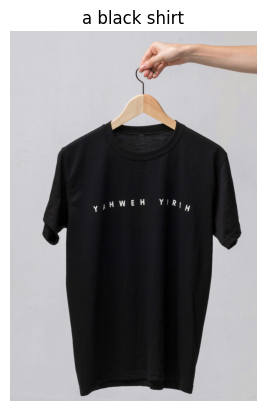

In [35]:
import matplotlib.pyplot as plt

img = Image.open(files[2])

plt.imshow(img)
plt.title(query)
plt.axis("off")
plt.show()

## 3. 모델 융합(YOLO + CLIP)

In [36]:
# 나는 이미지에서 사람이 앉아있는지 아닌지를 분류하고 싶습니다.
# sit.jpg 준비
# YOLO로 person 찾기
# CLIP 실습을 활용해서 person 분류하기

#### 모델 불러오기

In [38]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00


In [39]:
from ultralytics import YOLO

yolo_model = YOLO("./models/yolo26n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [40]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [41]:
yolo_model = yolo_model.to(device)
clip_model = clip_model.to(device)

#### 이미지/텍스트 준비하기

In [42]:
image_path = "/content/sit.jpg"
classes = [
    "a person standing",
    "a person sitting"
]

#### YOLO로 객체 감지하기

In [43]:
yolo_result = yolo_model(source=image_path)[0]
yolo_result


image 1/1 /content/sit.jpg: 640x512 1 person, 588.7ms
Speed: 30.4ms preprocess, 588.7ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 512)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [44]:
# yolo 찾은 사람 1명의 bounding box 정보
yolo_result.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.])
conf: tensor([0.8240])
data: tensor([[1.3059e+03, 1.6903e+03, 2.1977e+03, 3.9156e+03, 8.2396e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (4220, 3376)
shape: torch.Size([1, 6])
xywh: tensor([[1751.7830, 2802.9741,  891.7544, 2225.2502]])
xywhn: tensor([[0.5189, 0.6642, 0.2641, 0.5273]])
xyxy: tensor([[1305.9058, 1690.3489, 2197.6602, 3915.5991]])
xyxyn: tensor([[0.3868, 0.4006, 0.6510, 0.9279]])

In [ ]:
names = yolo_result.names
boxes = yolo_result.boxes

person_list = []
for data in boxes.data:
    x1, y1, x2, y2, conf, idx = data.to("cpu")
    if names[int(idx)] == "person":
        person_list.append(data.to("cpu"))

In [ ]:
# x1, y1, x2, y2, conf, idx
print(person_list)

#### 객체 감지한 결과에서 CLIP으로 분류하기

In [ ]:
import matplotlib.pyplot as plt

print(image_path)
image2 = Image.open(image_path).convert("RGB")

plt.imshow(image2)
plt.axis("off")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

x1, y1, x2, y2, conf, idx = person_list[0]
crop_image = image2.crop([int(x1), int(y1), int(x2), int(y2)])

plt.imshow(crop_image)
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image

image = Image.open(image_path)

for data in person_list:
    x1, y1, x2, y2, conf, idx = data
    crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

    inputs = processor(
        text=classes,
        images=crop_image,
        return_tensors="pt",
        padding=True
    ).to(device)

    # print(inputs)

    with torch.no_grad():
        output = clip_model(**inputs)
        logits_per_image = output.logits_per_image
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    best = classes[probs.argmax()]
    print(f"{best} {probs.max(): .4f}")